# 06 · Decision Framework

Five notebooks of simulation reduce to one flowchart and four rules.

The point of this notebook is that you should not have to redo any of that work. You need to
know which test to reach for, and what to check before you trust the number it gives you.

In [1]:
# Make the project importable whether this notebook is run from notebooks/ or the repo root.
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import warnings

import numpy as np

from src.config import get_settings, save_results
from src.evaluation.comparison import check_assumptions, compare_groups
from src.simulation.scenarios import make_scenario
from src.visualisation import plot_decision_flowchart, save_figure

settings = get_settings()
alpha = settings.alpha
rng = np.random.default_rng(settings.notebooks.demo_seed)
figures: dict[str, str] = {}

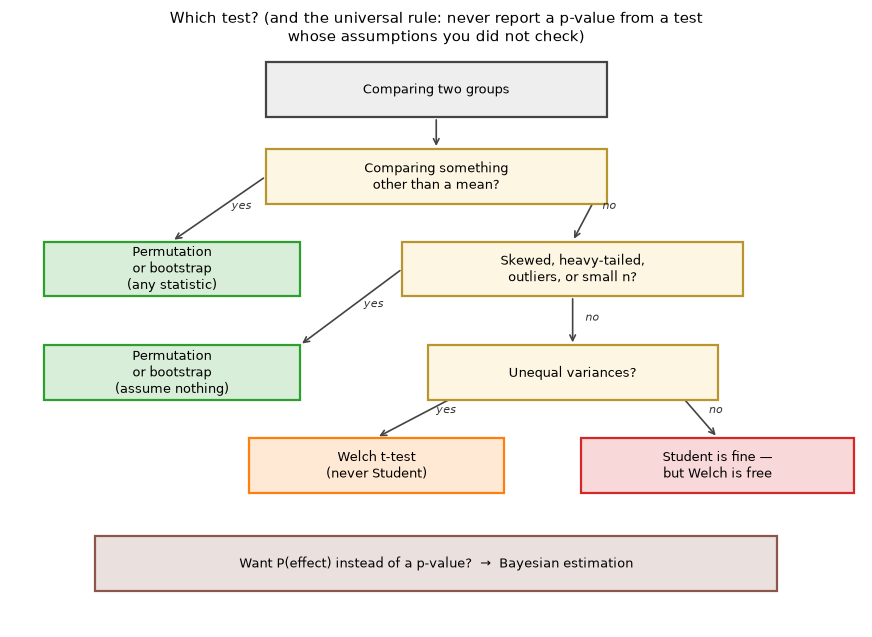

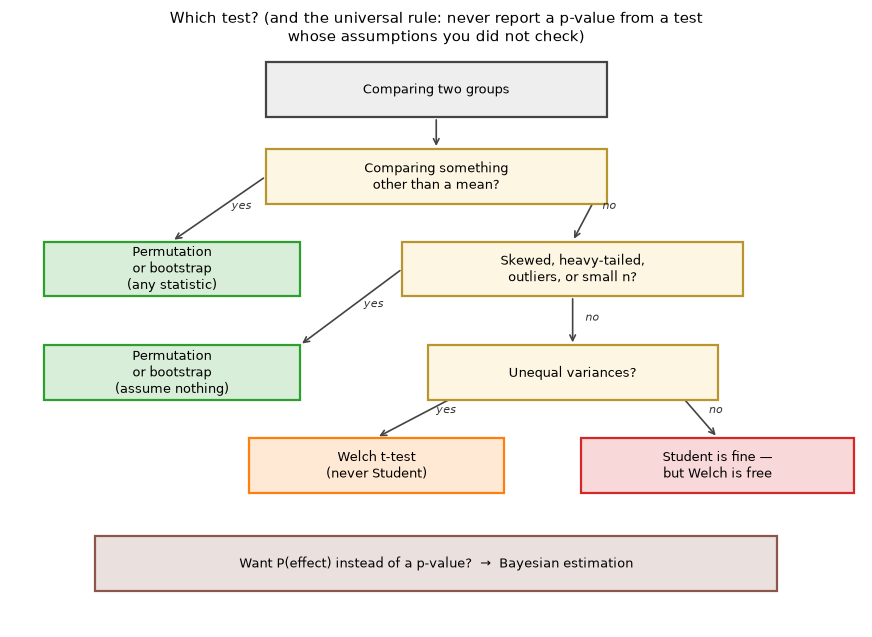

In [3]:
fig = plot_decision_flowchart()
figures["decision_flowchart"] = save_figure(fig, "06_decision_flowchart")
fig

## The same thing in words

| Your situation | Use | Why, from this project |
|---|---|---|
| Roughly normal, equal variances, balanced | Welch t | Student is fine here too, but Welch costs nothing and removes a failure mode |
| **Unequal variances** | **Welch t — never Student** | Student rejected 37.5% of the time at α = 0.05 with n = 100 vs 15 (notebook 02) |
| Skewed, heavy-tailed, outliers, or small n | Permutation or bootstrap | The only contender with a single inflated cell across the whole grid was the permutation test (notebook 04) |
| Comparing a **median, ratio, percentile** — anything but a mean | Permutation or bootstrap | They work for any statistic; the t-test only knows about means |
| You want "how big is it" | Bootstrap | It returns an interval on the scale of the data, not just a verdict |
| You want P(b beats a) | Bayesian estimation | It answers the question stakeholders actually asked |
| Skew *and* unequal spread *and* a small group | None of them, honestly | Every test in the arena ran 2.6–6.8× α there (notebook 04). Collect more data |

## The four rules

1. **Welch is the default.** There is no situation where Student is right and Welch is wrong.
2. **Check assumptions before trusting a parametric p-value.** Not after, and not never.
3. **When in doubt, use the assumption-free test.** Its only cost is compute, and compute is
   cheaper than a phantom discovery.
4. **Never report a p-value from a test whose assumptions you did not verify.**

## The tool

Rule 2 is the one that gets skipped, so the project ships it as code. `compare_groups` runs the
test you asked for and warns you when the data breaks its assumptions.

In [4]:
clean = make_scenario("clean", "normal", n_a=200, n_b=200, effect_d=0.3, settings=settings)
a_clean, b_clean = clean.draw(rng)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    result = compare_groups(a_clean, b_clean, test="welch", alpha=alpha)

print("CLEAN DATA, Welch")
print(f"  p = {result.p_value:.5f}   effect = {result.effect:.3f}   reject = {result.reject}")
print(f"  warnings: {len(caught)}")

CLEAN DATA, Welch
  p = 0.00016   effect = 0.352   reject = True
  warnings: 0


In [5]:
nasty = make_scenario("nasty", "lognormal", n_a=80, n_b=12, sd_ratio=3.0, settings=settings)
a_nasty, b_nasty = nasty.draw(rng)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    result = compare_groups(a_nasty, b_nasty, test="student", alpha=alpha)

print("SKEWED, UNBALANCED, UNEQUAL SPREAD — the worst case, with Student")
print(f"  p = {result.p_value:.5f}   effect = {result.effect:.3f}   reject = {result.reject}")
print(f"  warnings: {len(caught)}")
for w in caught:
    print(f"    ! {w.message}")

SKEWED, UNBALANCED, UNEQUAL SPREAD — the worst case, with Student
  p = 0.90448   effect = -0.362   reject = False
  warnings: 4
    ! student t-test: small sample (n = 80, 12): the t-test's normal approximation is doing work it cannot support, and a normality test here has almost no power
    ! student t-test: skewed data (skewness 3.21, 2.76): the mean may be the wrong summary; consider a permutation test on a median or trimmed mean
    ! student t-test: normality rejected (Shapiro-Wilk p = 7.417e-12): prefer an assumption-free test
    ! student t-test: 8.3% of observations are far outliers: they inflate the variance estimate and drain the t-test's power


Four warnings, on data where notebook 04 measured every test running well above α. The p-value
printed above is not trustworthy, and the point of the tool is that you find that out at the
moment you compute it rather than after you have shipped it.

The report is also available on its own, without running a test:

In [6]:
report = check_assumptions(a_nasty, b_nasty)
print(f"n = {report.n_a}, {report.n_b}")
print(f"skewness = {report.skewness_a:.2f}, {report.skewness_b:.2f}")
print(f"sd ratio = {report.sd_ratio:.2f}")
print(f"Shapiro-Wilk p = {report.normality_p_a:.3g}, {report.normality_p_b:.3g}")
print(f"far outliers = {report.outlier_fraction:.1%}")
print(f"clean? {report.clean}")

n = 80, 12
skewness = 3.21, 2.76
sd ratio = 1.87
Shapiro-Wilk p = 7.42e-12, 2.17e-05
far outliers = 8.3%
clean? False


**One caution about that report, which matters more than it looks.** A normality test on 12
observations has almost no power, so a passing Shapiro–Wilk p-value on a small sample is not
evidence of normality — it is evidence that you did not have enough data to detect the
non-normality. That is why the small-sample check fires independently of the normality check.

The absence of a warning is not a licence. It is the absence of an *obvious* problem.

## And the default

`compare_groups` defaults to the permutation test, not to a t-test. That is the whole project in
one line of API design: when you have not checked, the assumption-free option is the one that
does not quietly cost you.

In [7]:
default_result = compare_groups(a_nasty, b_nasty, alpha=alpha, rng=np.random.default_rng(1))
print(f"default test: {default_result.name}")
print(f"  p = {default_result.p_value:.4f}   effect = {default_result.effect:.3f}")

default test: permutation
  p = 0.9540   effect = -0.362


## Where this goes next

- **More than two groups** — ANOVA versus Kruskal–Wallis and permutation.
- **Paired designs** — the matched-sample versions and their own assumptions.
- **Multiple comparisons** — Bonferroni and Benjamini–Hochberg, picking up notebook 05's twenty
  metrics.
- **Equivalence testing** — proving two groups are the *same*, the inverse question almost
  nobody asks.

## The one-sentence version

The t-test you were taught assumes a bell curve and equal variances your data probably does not
have; Welch fixes half of that for free, the permutation test fixes the rest for the price of a
few hundred shuffles, and neither of them can save you if you did not look at your data first.

In [8]:
decision_rules = [
    {"situation": "roughly normal, equal variances, balanced groups",
     "use": "Welch t", "reason": "Student is also fine, but Welch removes a failure mode free"},
    {"situation": "unequal variances",
     "use": "Welch t (never Student)",
     "reason": "Student rejected 37.5% at alpha=0.05 with n=100 vs 15 and no real difference"},
    {"situation": "skewed, heavy-tailed, outliers, or small n",
     "use": "permutation or bootstrap",
     "reason": "permutation was the only contender with a single inflated null cell in the grid"},
    {"situation": "comparing a median, ratio or percentile",
     "use": "permutation or bootstrap", "reason": "they work for any statistic"},
    {"situation": "you want the size of the effect",
     "use": "bootstrap", "reason": "returns an interval on the scale of the data"},
    {"situation": "you want P(b > a)",
     "use": "Bayesian estimation", "reason": "answers the question stakeholders asked"},
    {"situation": "skew AND unequal spread AND a small group",
     "use": "none are reliable", "reason": "every test ran 2.6-6.8x alpha; collect more data"},
]

summary = {
    "notebook": "06_decision_framework",
    "settings": {"profile": settings.profile, "alpha": alpha, "seed": settings.seed},
    "decision_rules": decision_rules,
    "universal_rules": [
        "Welch is the default; there is no case where Student is right and Welch is wrong.",
        "Check assumptions before trusting a parametric p-value.",
        "When in doubt use the assumption-free test; its only cost is compute.",
        "Never report a p-value from a test whose assumptions you did not verify.",
    ],
    "compare_groups_demo": {
        "clean": {"n_a": clean.n_a, "n_b": clean.n_b, "n_warnings": 0},
        "nasty": {
            "n_a": nasty.n_a, "n_b": nasty.n_b, "sd_ratio": nasty.sd_ratio,
            "warnings": [str(w.message) for w in caught],
        },
        "default_test": default_result.name,
    },
    "assumption_report": {
        "n_a": report.n_a, "n_b": report.n_b,
        "skewness_a": report.skewness_a, "skewness_b": report.skewness_b,
        "sd_ratio": report.sd_ratio,
        "normality_p_a": report.normality_p_a, "normality_p_b": report.normality_p_b,
        "outlier_fraction": report.outlier_fraction,
        "messages": report.messages, "clean": report.clean,
    },
    "figures": figures,
    "claims": [
        "Welch should be the default two-sample t-test; there is no situation in this project "
        "where Student is correct and Welch is not.",
        "For skewed, heavy-tailed, outlier-prone or small samples, use a permutation or "
        "bootstrap test, which assume nothing about the shape.",
        "Permutation and bootstrap work for any statistic, so they are the only option when "
        "comparing medians, ratios or percentiles.",
        "A passing normality test on a small sample is not evidence of normality; it is "
        "evidence of insufficient power to detect non-normality.",
        "compare_groups defaults to the permutation test and warns when the chosen test's "
        "assumptions are violated by the data.",
    ],
}
print(save_results("06_decision_framework", summary))

/workspaces/hypothesis_testing_arena/outputs/results/06_decision_framework.json
